# 猫狗分类：从课堂CNN到模型对照

本案例由老师的 `cifar10_cnn_teaching_case.ipynb` 改编。保留图像归一化、卷积、池化、BatchNormalization和Dropout，改为猫狗二分类，加入MLP基线与数据增强消融。默认浏览已经跑出的结果；完整训练放在 `catdog_case.py`。

In [1]:
from pathlib import Path
import json
import os
from IPython.display import display, Image
import pandas as pd
from catdog_case import main
OUT = Path('results')
RETRAIN = False
if RETRAIN:
    archive = Path(os.environ['CIFAR_ARCHIVE']) if os.environ.get('CIFAR_ARCHIVE') else None
    main(archive, OUT, epochs=20)
summary = json.loads((OUT/'summary.json').read_text(encoding='utf-8'))

## 1. 数据准备

CIFAR-10图片大小为32×32，猫的原标签为3，狗为5。筛选后将猫改为0，狗改为1。官方训练样本按固定种子分层拆成8000张训练图和2000张验证图，另保留2000张官方测试图。

split: {'train': 8000, 'validation': 2000, 'test': 2000}
counts: {'train': [4000, 4000], 'validation': [1000, 1000], 'test': [1000, 1000]}


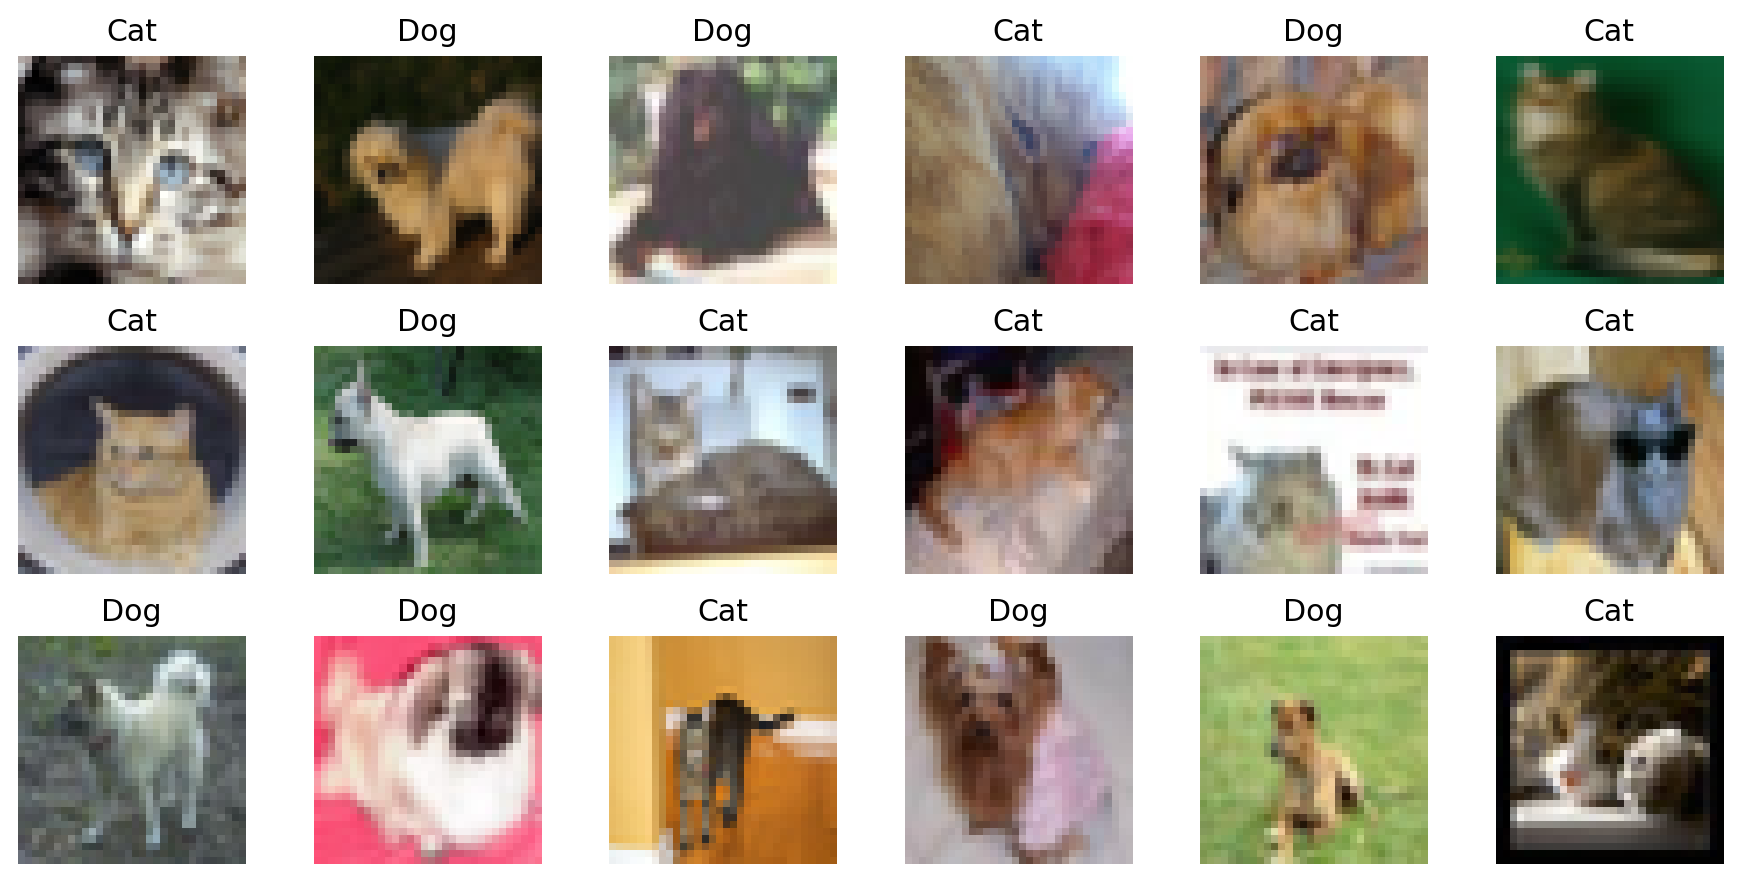

In [2]:
print('split:', summary['split'])
print('counts:', summary['counts'])
display(Image(filename=str(OUT/'figures/05_samples.png')))

## 2. 先做MLP，再做CNN

MLP把图像展开为向量。CNN保留邻近像素关系，用共享卷积核提取局部特征。普通CNN与增强CNN结构和参数量相同，增强CNN额外加入水平翻转、轻度旋转和缩放。

,Model,Parameters,Best_Epoch,Val_Accuracy,Test_Accuracy,Test_Macro_F1
0,MLP,393473,11,0.5745,0.598,0.597110
1,CNN,89585,20,0.7450,0.758,0.757752
2,CNN_aug,89585,20,0.7435,0.743,0.742720


selected by validation loss: CNN


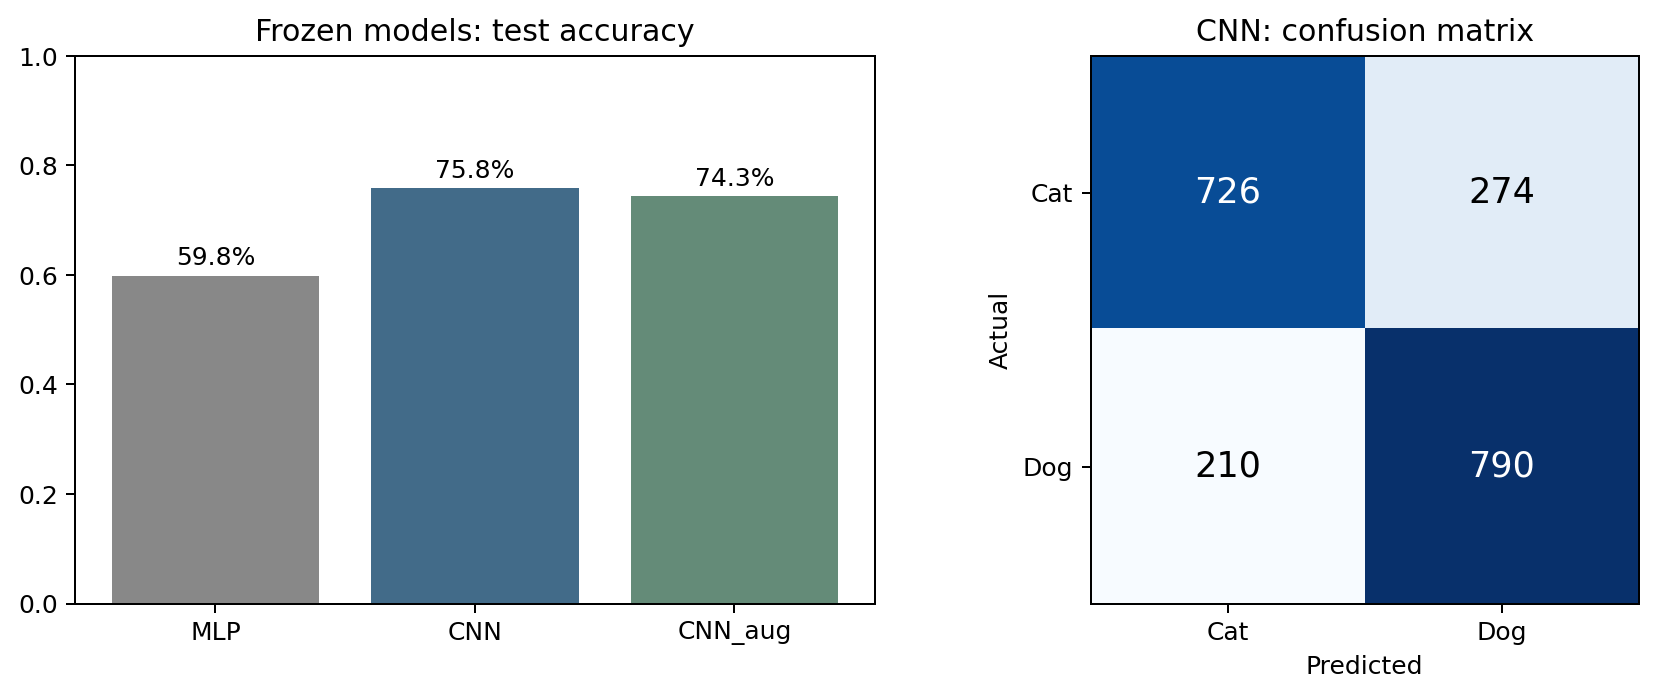

In [3]:
rows=[]
for name, r in summary['models'].items():
    rows.append({'Model': name, 'Parameters': r['parameters'], 'Best_Epoch':r['best_epoch'], 'Val_Accuracy':r['validation']['accuracy'], 'Test_Accuracy':r['test']['accuracy'], 'Test_Macro_F1':r['test']['macro_f1']})
display(pd.DataFrame(rows))
print('selected by validation loss:', summary['selected_model'])
display(Image(filename=str(OUT/'figures/02_metrics.png')))

## 3. 训练曲线与提前停止

优化器为Adam，学习率0.001，每批128张，最多20轮。监控验证交叉熵，连续5轮没有改善便停止并恢复最佳权重。每个模型的回调单独创建。

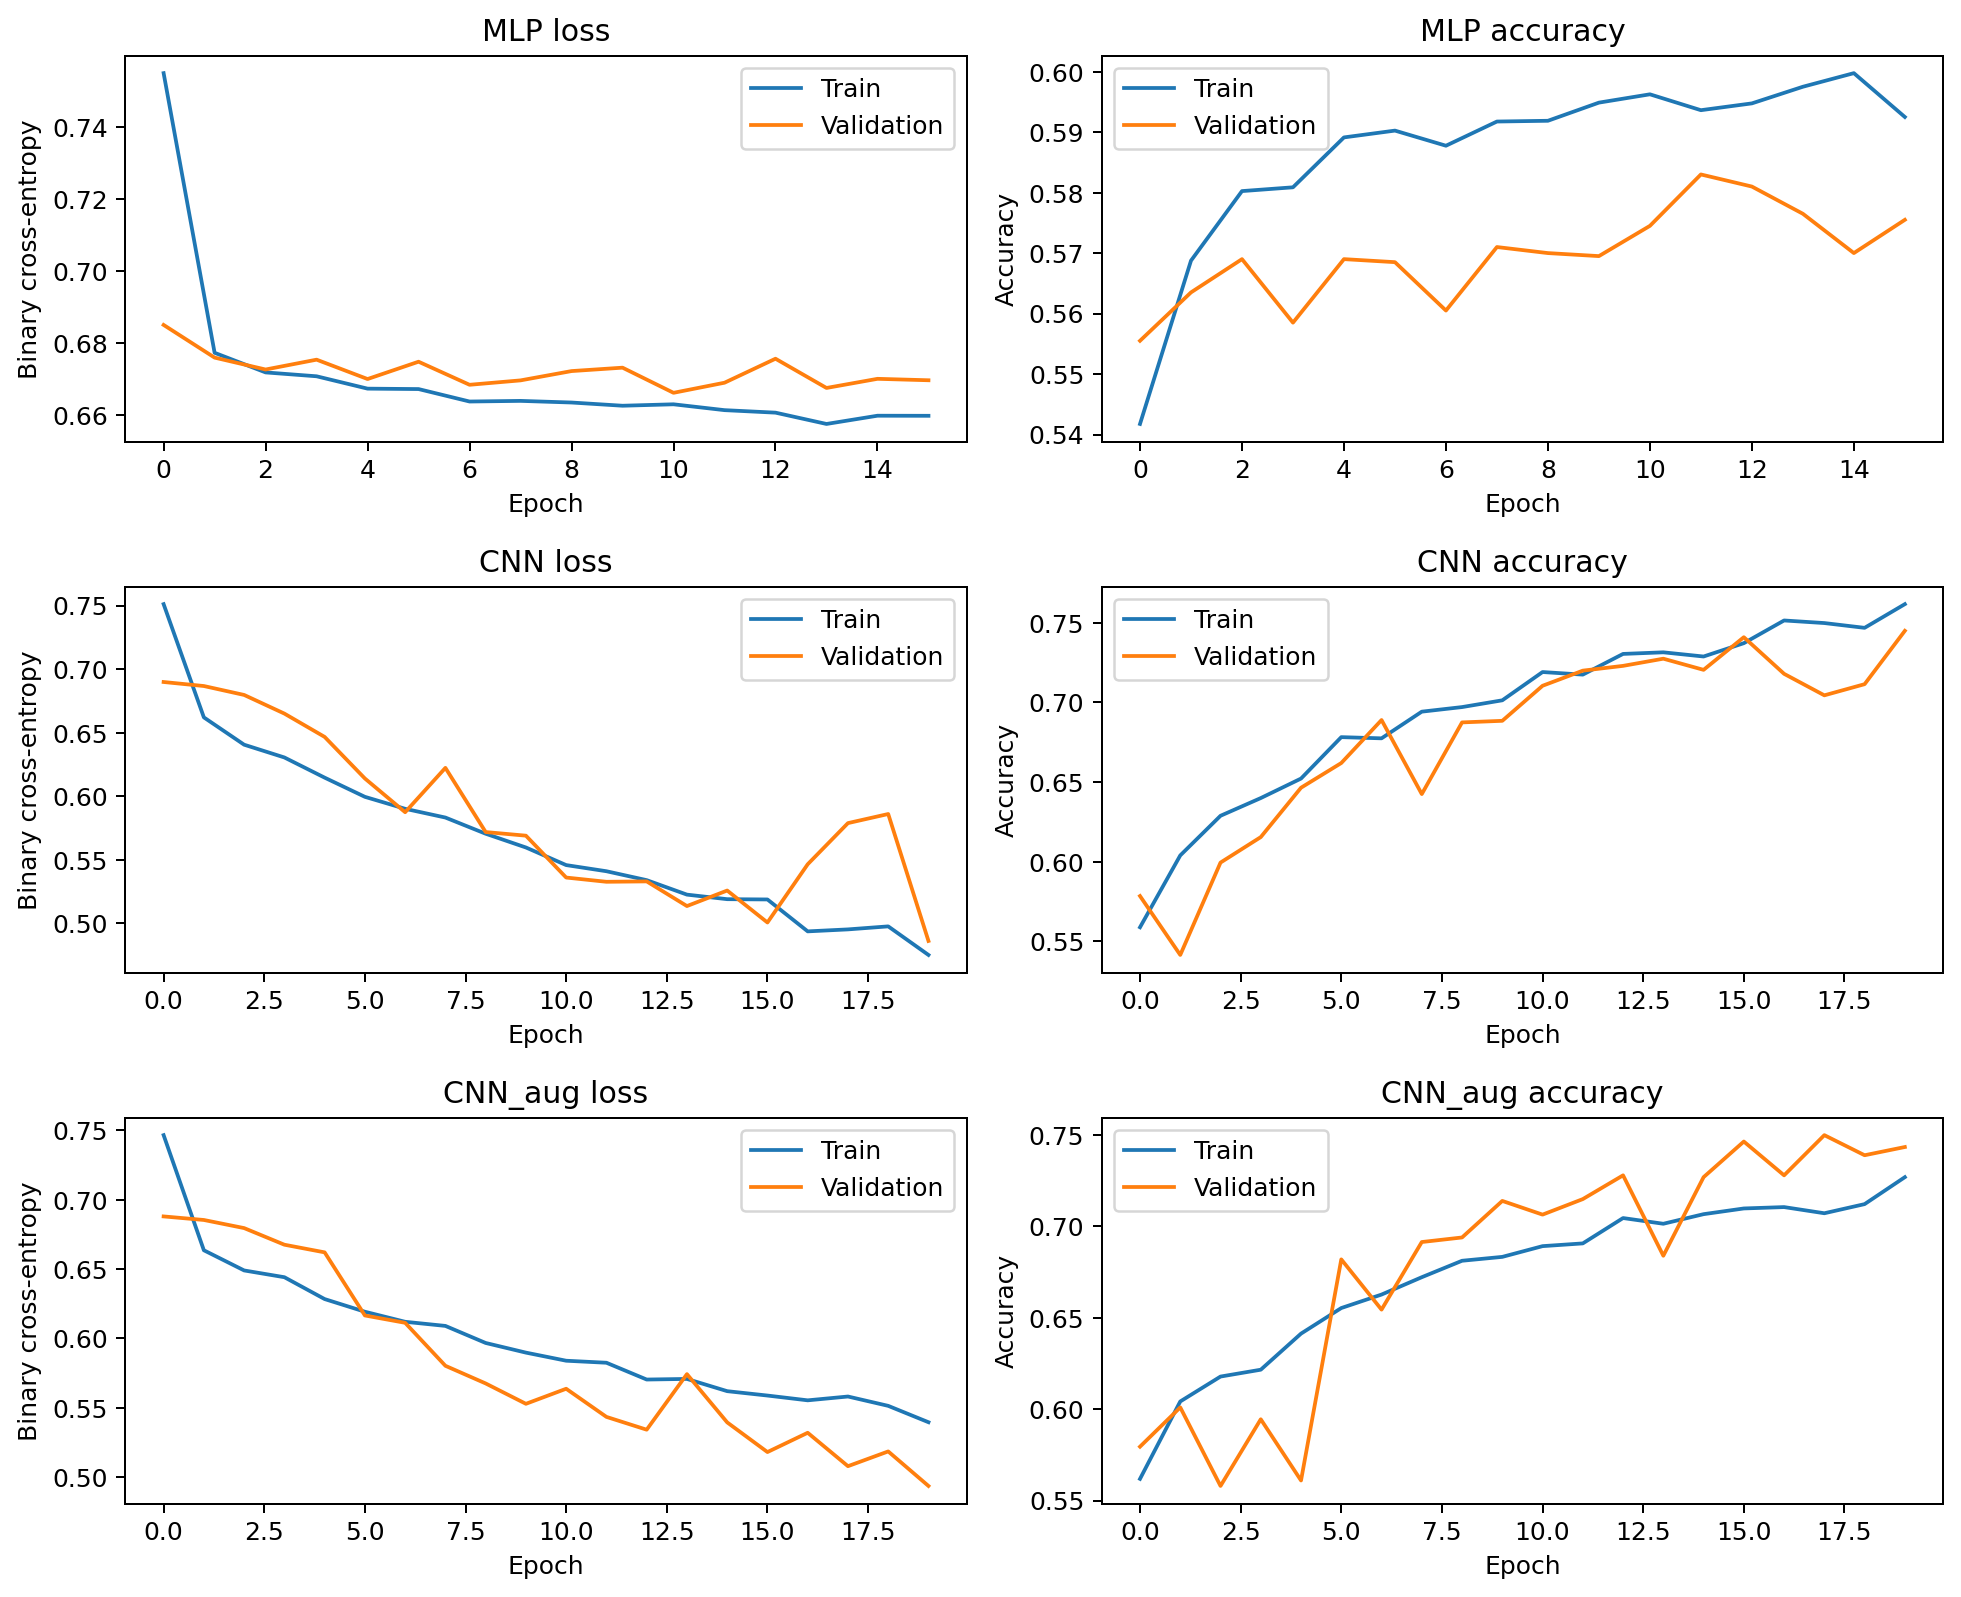

In [4]:
display(Image(filename=str(OUT/'figures/01_learning_curves.png')))

## 4. 错误样本

查看错误时保留真实标签、预测标签和模型分数。分数很高也可能分类错误；这次没有做概率校准，因此不把0.98的分数解释为98%的可靠正确率。

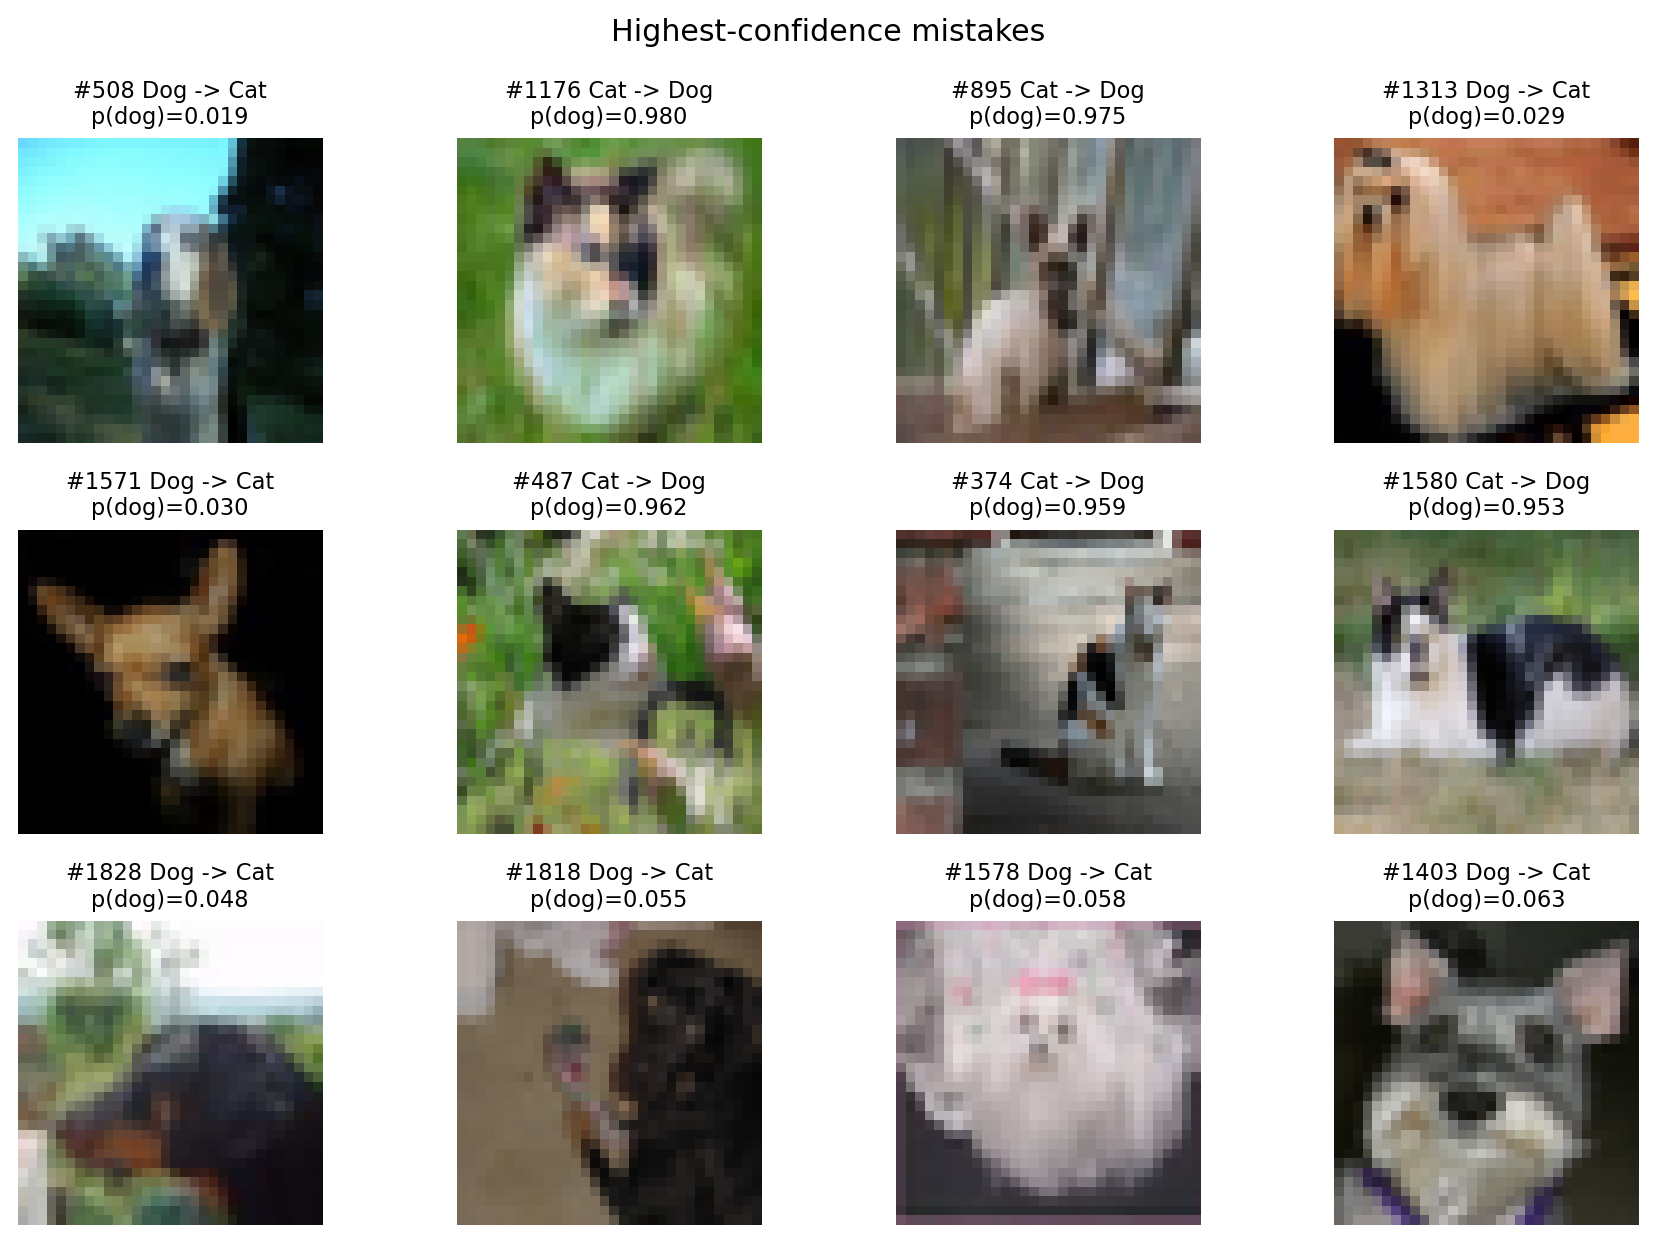

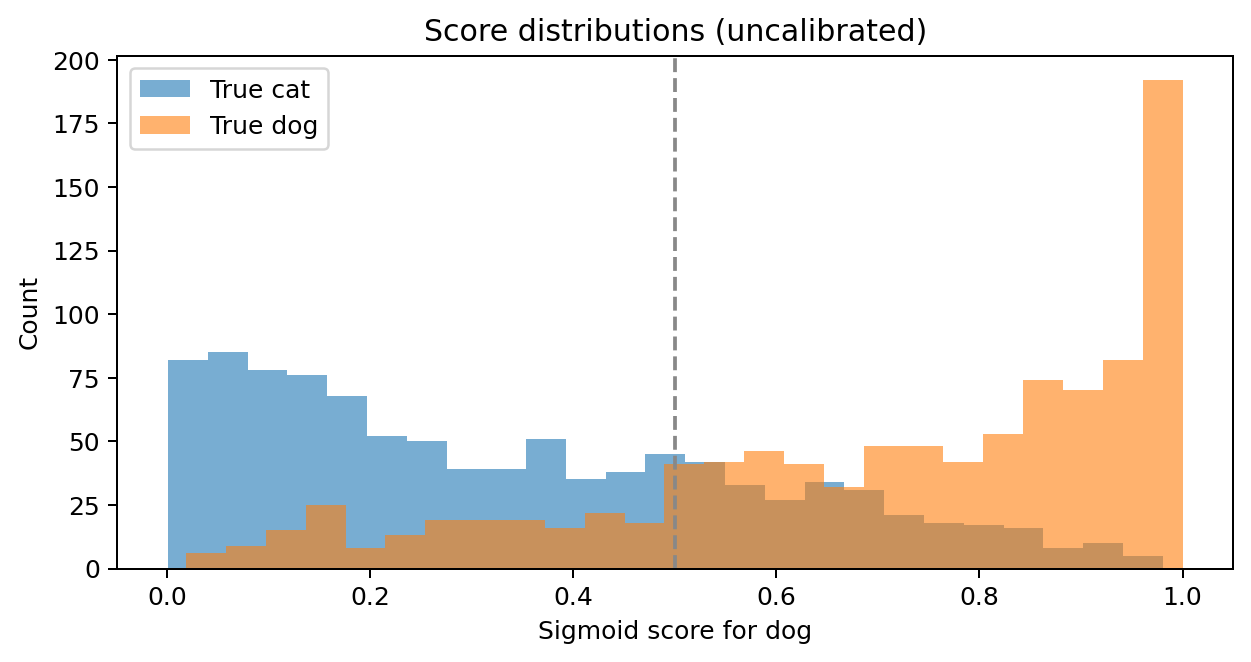

In [5]:
display(Image(filename=str(OUT/'figures/03_wrong_examples.png')))
display(Image(filename=str(OUT/'figures/04_scores.png')))

## 5. 加载模型做单图预测

两张演示图取自官方测试集各类别的首张样本。它们只用来确认保存、读取、预处理和预测可以连起来，整体效果以上方2000张测试集评估为准。

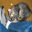

example_cat.png {'预测类别': '猫', '狗分数': 0.19714972376823425, '猫分数': 0.8028502762317657, '适用范围': '仅对一张图片中的猫或狗进行二选一；其他物体也会被强行归类。'}


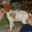

example_dog.png {'预测类别': '猫', '狗分数': 0.4148132801055908, '猫分数': 0.5851867198944092, '适用范围': '仅对一张图片中的猫或狗进行二选一；其他物体也会被强行归类。'}


In [6]:
from predict import predict
for p in [Path('example_cat.png'), Path('example_dog.png')]:
    display(Image(filename=str(p), width=160))
    print(p.name, predict(p, OUT/'catdog_selected.keras'))

## 6. 结果与改进

普通CNN测试准确率75.8%，MLP为59.8%，增加16.0个百分点。增强CNN为74.3%，没有在这次训练中改善表现。CNN参数更少但表现更好，说明增加参数本身不能代替合适的图像结构。这个比较同时涉及模型结构与正则化方式，不能把全部提升只归因于卷积。

低分辨率、主体偏小和背景复杂是错误图片中能观察到的现象。不能仅凭错误图确定模型在利用什么特征。后续可以尝试更长训练预算和多随机种子比较；真正做宠物识别工具时，还需要高分辨率数据、非猫狗图片测试和不确定性处理。

单图演示中的狗被误分为猫。示例使用官方测试集每类的首张图片，没有根据预测对错筛选；这次保留这个错误，整体能力仍以2000张测试集结果评估。